In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

# 1. Data Setup


from tf_keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

In [2]:
# 2. Simple CNN Model


from tf_keras import layers
from tf_keras import models

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

In [3]:
from tf_keras.datasets import mnist
from tf_keras.utils import to_categorical

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype('float32') / 255

test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype('float32') / 255

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=5, batch_size=64)


Epoch 1/5


938/938 [==============================] - 6s 6ms/step - loss: 0.2870 - accuracy: 0.9103
Epoch 2/5
938/938 [==============================] - 6s 6ms/step - loss: 0.0852 - accuracy: 0.9746
Epoch 3/5
938/938 [==============================] - 5s 6ms/step - loss: 0.0586 - accuracy: 0.9816
Epoch 4/5
938/938 [==============================] - 5s 6ms/step - loss: 0.0441 - accuracy: 0.9866
Epoch 5/5
938/938 [==============================] - 6s 6ms/step - loss: 0.0361 - accuracy: 0.9889


In [4]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("accuracy:",test_acc)

313/313 [==============================] - 1s 2ms/step - loss: 0.1179 - accuracy: 0.9644
accuracy: 0.9643999934196472


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_21 (Conv2D)          (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d_21 (MaxPooli  (None, 74, 74, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_22 (Conv2D)          (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_22 (MaxPooli  (None, 36, 36, 64)        0         
 ng2D)                                                           
                                                                 
 conv2d_23 (Conv2D)          (None, 34, 34, 128)       73856     
                                                                 
 max_pooling2d_23 (MaxPooli  (None, 17, 17, 128)      

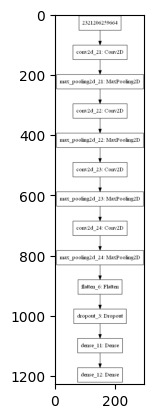

In [5]:
from tf_keras import models
from tf_keras.models import load_model

model = load_model('cats_and_dogs.h5')
model.summary()

from tf_keras.utils import plot_model
plot_model(model, to_file='model.png')

print("\nShow diagram:")
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
img= mpimg.imread('model.png')
plt.imshow(img)

Tensor shape: (1, 150, 150, 3)


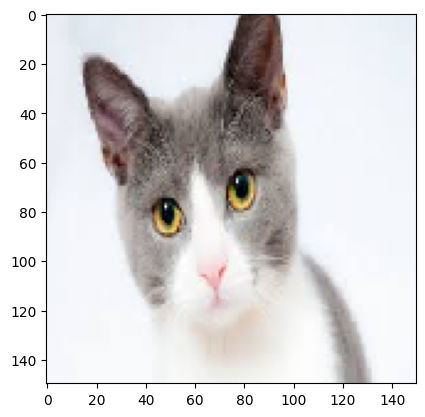

In [6]:
# 3. Pretrained Model Visualization (cats_and_dogs)

img_path = 'cat2.png'
from tf_keras.preprocessing import image
import numpy as np
img = image.load_img(img_path, target_size=(150, 150))
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis=0)
img_tensor /= 255.

print("Tensor shape:",img_tensor.shape)

import matplotlib.pyplot as plt
plt.imshow(img_tensor[0])
plt.show()

In [7]:
from tf_keras import models
from tf_keras import layers


temp_model = models.Sequential()
temp_model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
temp_model.add(layers.MaxPooling2D((2, 2)))
temp_model.add(layers.Conv2D(64, (3, 3), activation='relu'))
temp_model.add(layers.MaxPooling2D((2, 2)))
temp_model.add(layers.Conv2D(128, (3, 3), activation='relu'))
temp_model.add(layers.MaxPooling2D((2, 2)))
temp_model.add(layers.Conv2D(128, (3, 3), activation='relu'))
temp_model.add(layers.MaxPooling2D((2, 2)))
temp_model.add(layers.Flatten())
temp_model.add(layers.Dense(512, activation='relu'))
temp_model.add(layers.Dense(2, activation='softmax'))

model = temp_model

layer_outputs = [layer.output for layer in model.layers[:8]]
activation_model = models.Model(inputs=model.layers[0].input, outputs=layer_outputs)

activations = activation_model.predict(img_tensor)
first_layer_activation = activations[0]

1/1 [==============================] - 0s 64ms/step



In my case the forth channel detects diagonal edges.
But your result can differ while specific filters learned by CNN are not deterministic.


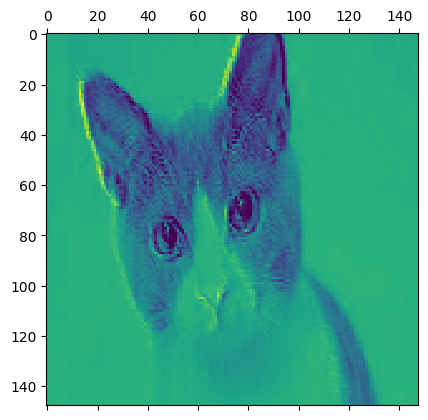

In [8]:
import matplotlib.pyplot as plt
plt.matshow(first_layer_activation[0, :, :, 4], cmap='viridis')
print("\nIn my case the forth channel detects diagonal edges.\nBut your result can differ while specific filters learned by CNN are not deterministic.")

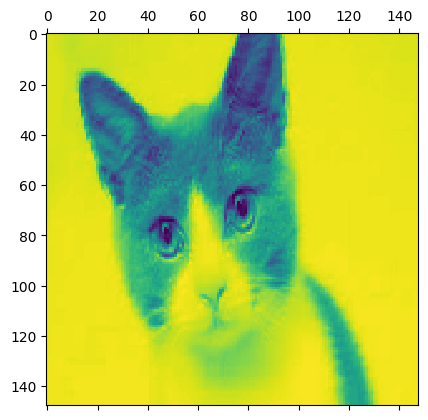

In [9]:
plt.matshow(first_layer_activation[0, :, :, 7], cmap='viridis')

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17444\2416711597.py:21: RuntimeWarning: invalid value encountered in divide
  channel_image /= channel_image.std()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17444\2416711597.py:24: RuntimeWarning: invalid value encountered in cast
  channel_image = np.clip(channel_image, 0, 255).astype('uint8')


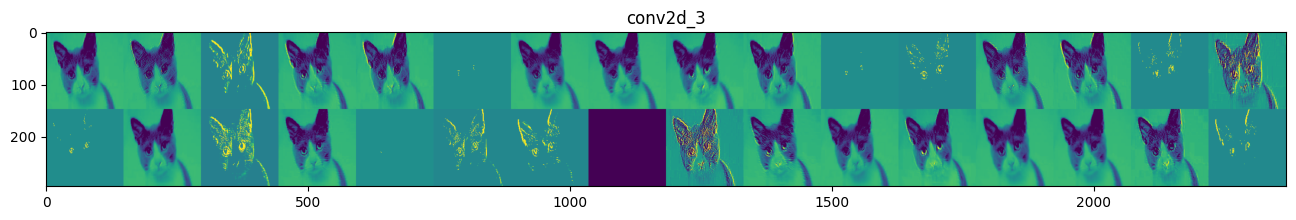

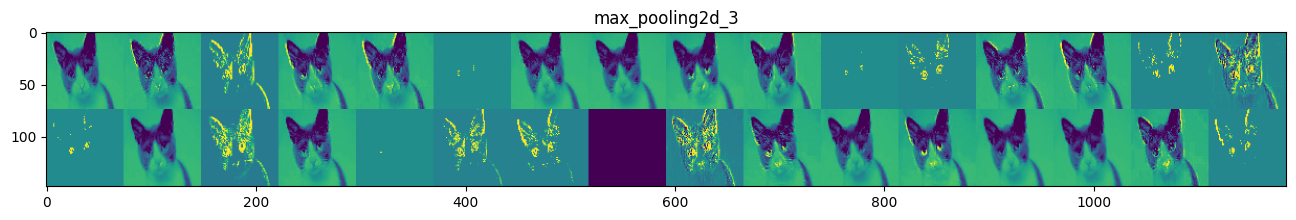

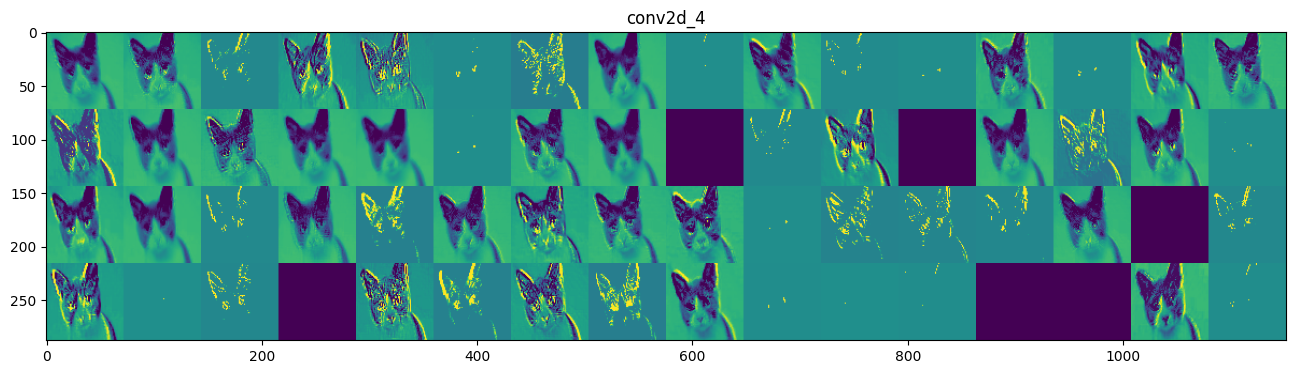

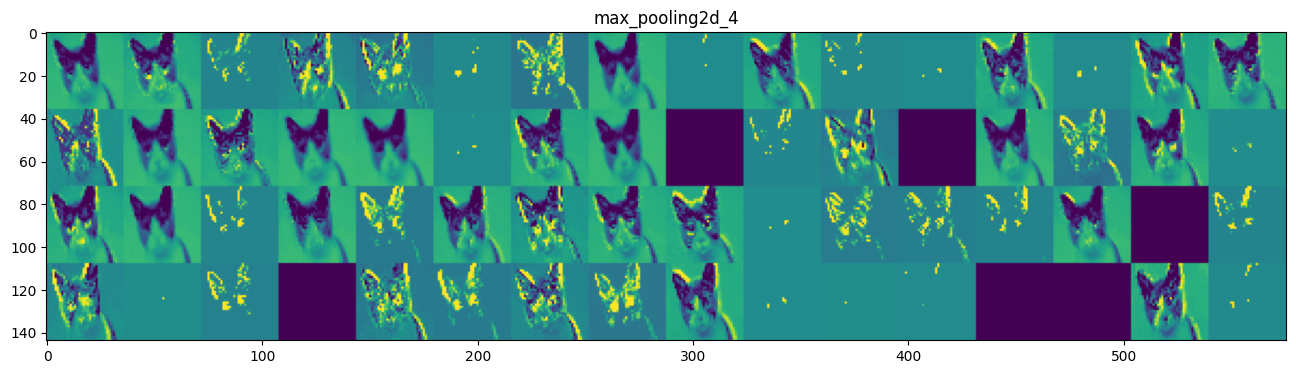

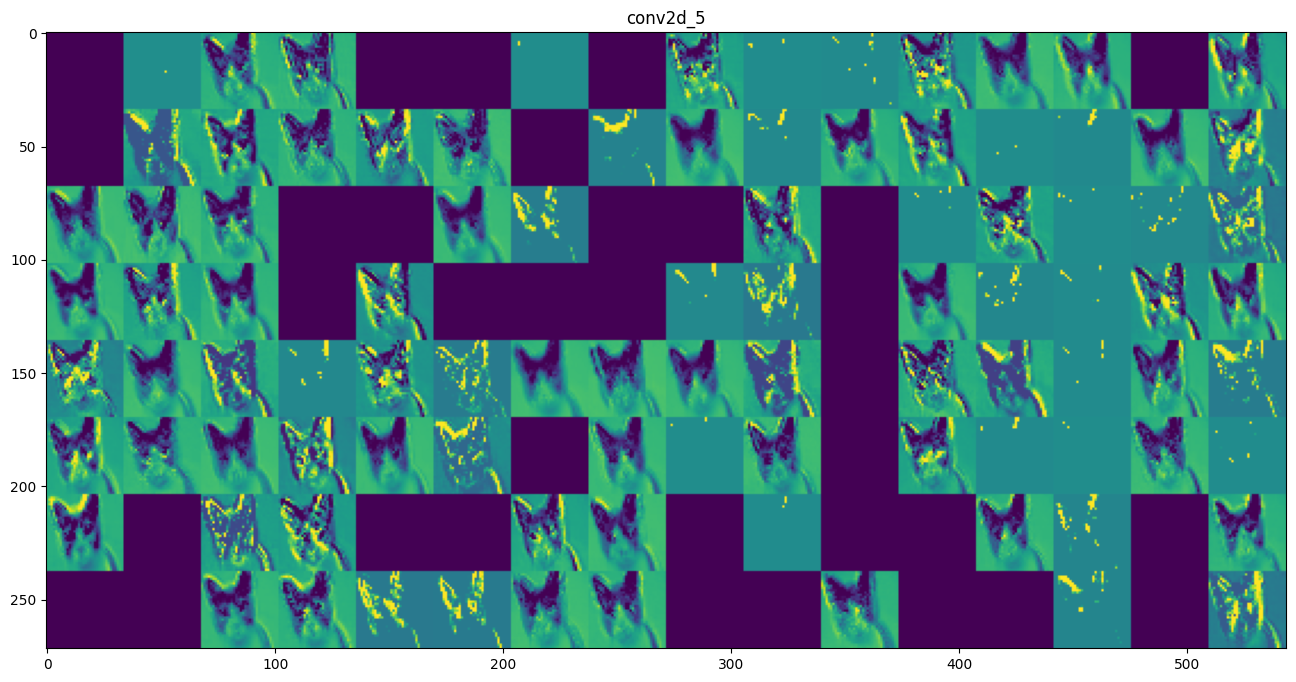

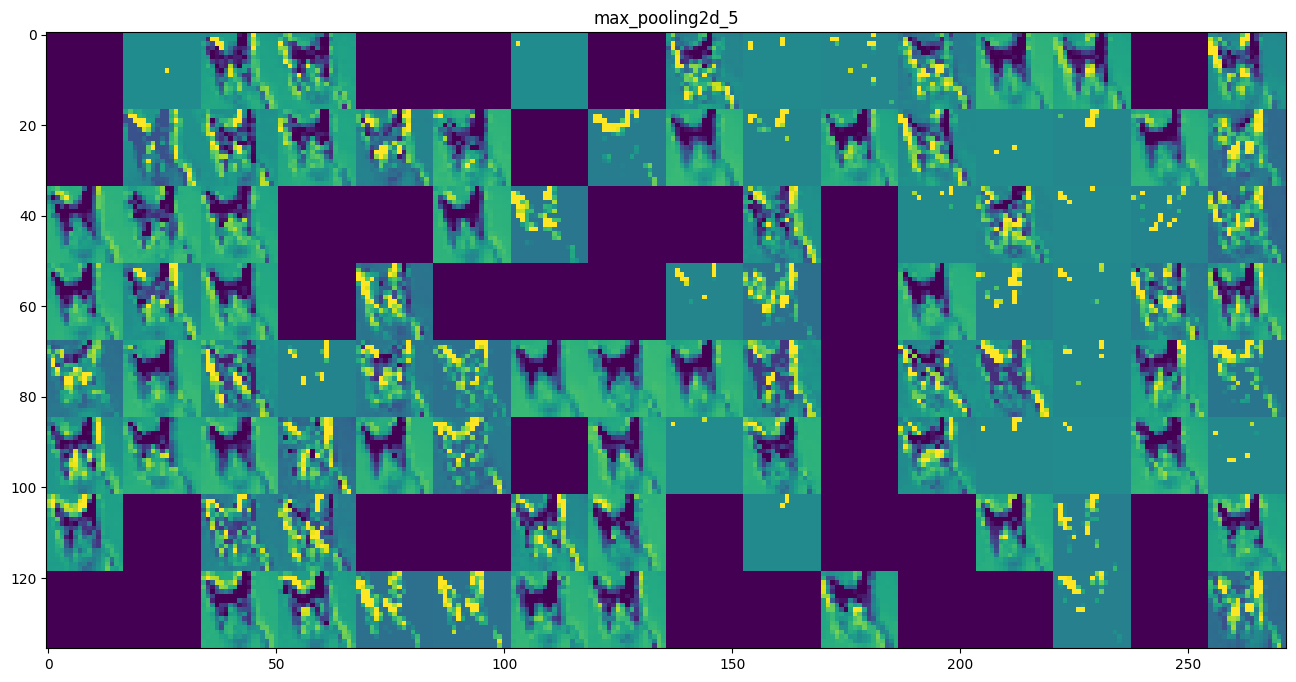

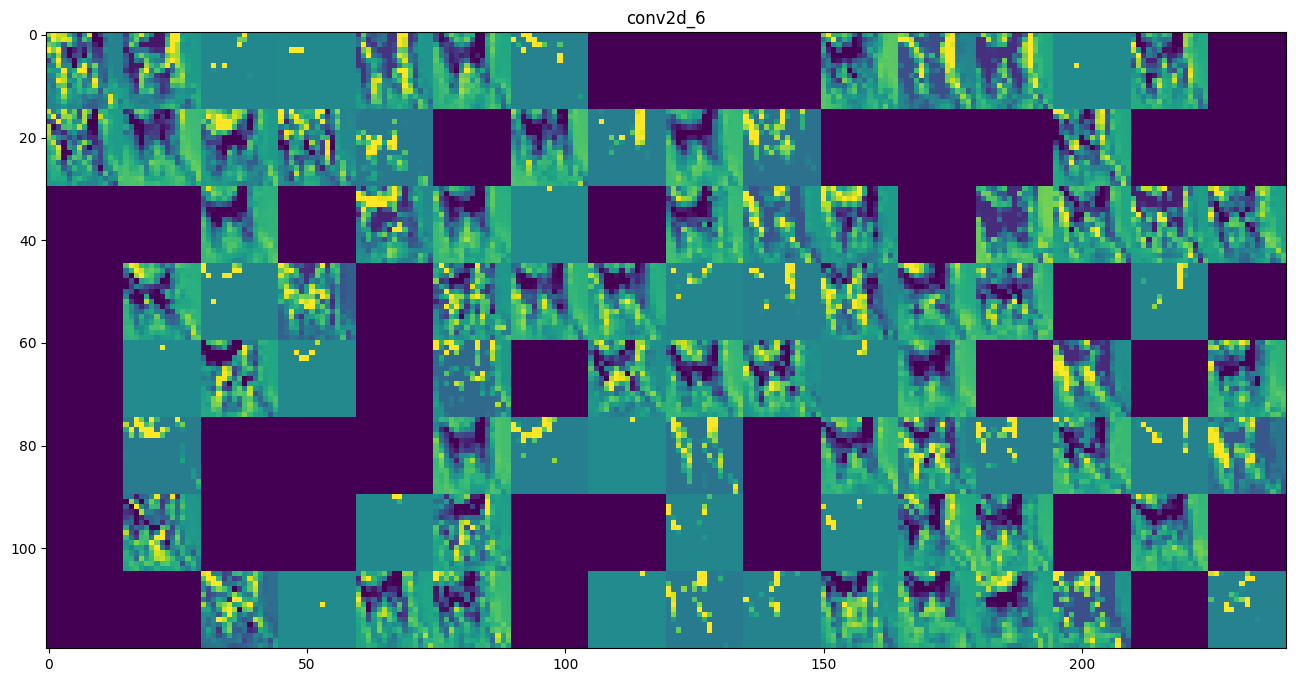

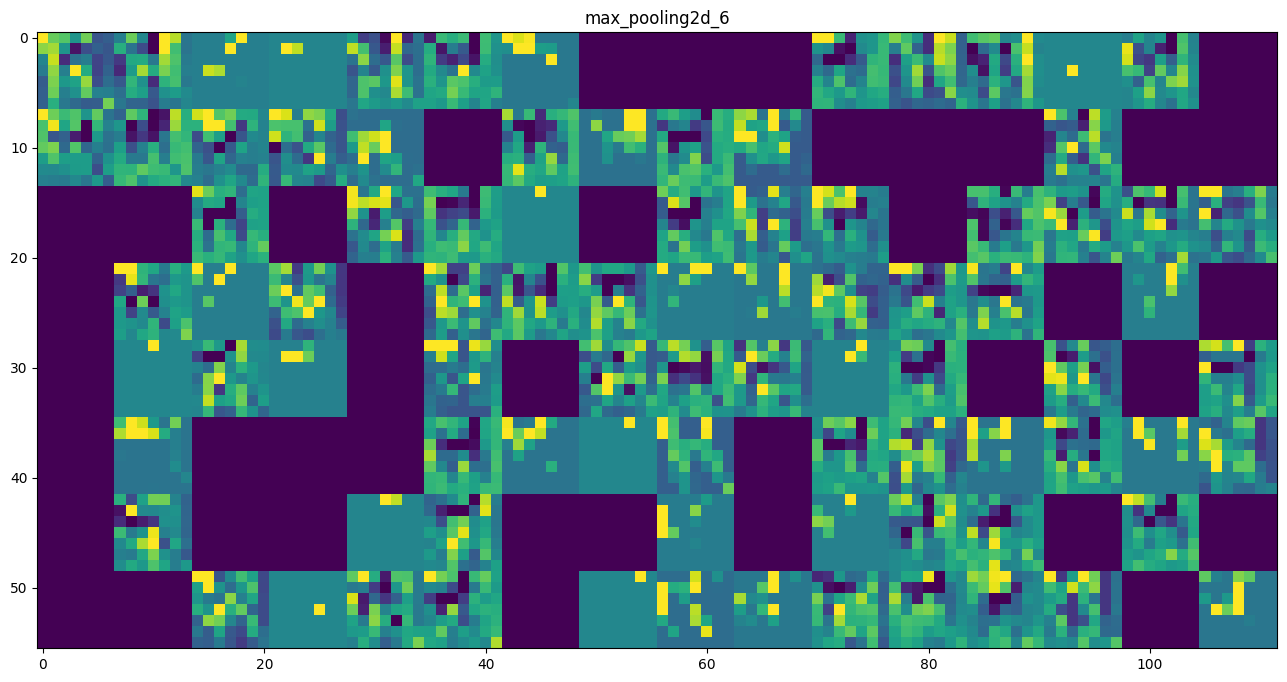

In [10]:

layer_names = []
for layer in model.layers[:8]:
    layer_names.append(layer.name)

images_per_row = 16

for layer_name, layer_activation in zip(layer_names, activations):
    n_features = layer_activation.shape[-1]

    size = layer_activation.shape[1]

    n_cols = n_features // images_per_row
    display_grid = np.zeros((size * n_cols, images_per_row * size))

    for col in range(n_cols):
        for row in range(images_per_row):
            channel_image = layer_activation[0,
                                             :, :,
                                             col * images_per_row + row]
            channel_image -= channel_image.mean()
            channel_image /= channel_image.std()
            channel_image *= 64
            channel_image += 128
            channel_image = np.clip(channel_image, 0, 255).astype('uint8')
            display_grid[col * size : (col + 1) * size,
                         row * size : (row + 1) * size] = channel_image

    scale = 1. / size
    plt.figure(figsize=(scale * display_grid.shape[1],
                        scale * display_grid.shape[0]))
    plt.title(layer_name)
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')

In [11]:
# 4. VGG16 Pretrained Model

from tf_keras.applications.vgg16 import VGG16
model = VGG16(weights='imagenet')

from tf_keras.preprocessing import image
from tf_keras.applications.vgg16 import preprocess_input, decode_predictions
import numpy as np

In [12]:
img_path = 'elephant1.png'
img = image.load_img(img_path, target_size=(224, 224))

x = image.img_to_array(img)

x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

preds = model.predict(x)
print('most probably 3 classes:\n', decode_predictions(preds, top=3)[0])
print('predicted class number:\n',np.argmax(preds[0]))

1/1 [==============================] - 0s 205ms/step
most probably 3 classes:
 [('n02504458', 'African_elephant', np.float32(0.8887978)), ('n01871265', 'tusker', np.float32(0.10223694)), ('n02504013', 'Indian_elephant', np.float32(0.008635407))]
predicted class number:
 386


In [13]:
# 5. Grad-CAM Implementation

import tensorflow as tf
from tf_keras import backend as K

african_elephant_class_idx = 386

last_conv_layer = model.get_layer('block5_conv3')

grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[last_conv_layer.output, model.output]
)

with tf.GradientTape() as tape:
    x_tf = tf.cast(x, tf.float32)

    last_conv_layer_output, preds = grad_model(x_tf)

    class_channel = preds[:, african_elephant_class_idx]

grads = tape.gradient(class_channel, last_conv_layer_output)

pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

pooled_grads_value = pooled_grads.numpy()
conv_layer_output_value = last_conv_layer_output.numpy()[0] # Get the first (and only) image from batch

for i in range(pooled_grads_value.shape[-1]): # Iterate through the channels
    conv_layer_output_value[:, :, i] *= pooled_grads_value[i]

heatmap = np.mean(conv_layer_output_value, axis=-1)

print("pooled_grads_value (first 5 values):\n", pooled_grads_value[:5])
print("heatmap shape:", heatmap.shape)

pooled_grads_value (first 5 values):
 [ 3.4950101e-06 -2.1809574e-06  6.3940629e-06  3.6471360e-07
 -5.5876094e-06]
heatmap shape: (14, 14)


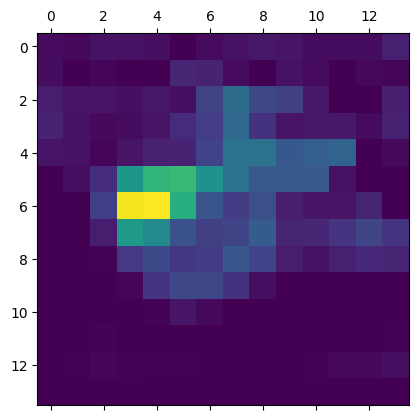

In [14]:
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)
plt.matshow(heatmap)


The most informative area of the image is the head of small elephant.


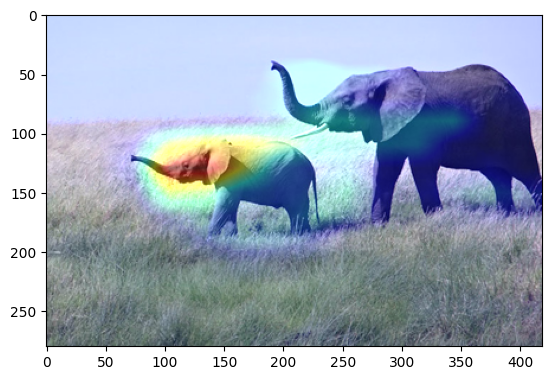

In [15]:
import cv2
import matplotlib.image as mpimg
img_name='elephant_heatmap.png'

img = cv2.imread(img_path)
heatmap2 = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

heatmap2 = np.uint8(255 * heatmap2)
heatmap2 = cv2.applyColorMap(heatmap2, cv2.COLORMAP_JET)

superimposed_img = heatmap2 * 0.4 + img
cv2.imwrite(img_name, superimposed_img)

img= mpimg.imread(img_name)
plt.imshow(img)
print("\nThe most informative area of the image is the head of small elephant.")

In [16]:
from tf_keras.layers import Embedding

embedding_layer = Embedding(1000, 64)